# Machine Learning Capstone Project

## Predicting Kickstarter Campaign Success

**Goal:** Predict campaign success using information available at launch.

# Part 1 – Problem and Dataset Understanding

- **Purpose:** Understand and predict Kickstarter campaign success.
- **Each row:** One completed campaign.
- **Target:** `success` (`1` = successful, `0` = failed).
- **Problem:** Binary Classification.
- **X:** Goal, category, country, currency, duration, and launch features.
- **Why ML:** Success depends on several features together.
- **Value:** Helps creators review a campaign before launch.

In [ ]:
# Import libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    silhouette_score
)
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [ ]:
# Load the dataset
df = pd.read_csv("kickstarter_campaign_success.csv")
print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully.
Rows: 3715
Columns: 13


The dataset is large enough for training and comparing multiple models.

# Part 2 – Initial Data Exploration

In [ ]:
# Dataset shape and column names
print("Shape:", df.shape)
print()
print("Columns:")
print(df.columns.tolist())

Shape: (3715, 13)

Columns:
['campaign_id', 'goal', 'country', 'currency', 'launched_date', 'deadline_date', 'category', 'subcategory', 'campaign_duration_days', 'launch_year', 'launch_month', 'launch_weekday', 'success']


In [ ]:
# Data types
print(df.dtypes)

campaign_id                 int64
goal                      float64
country                    object
currency                   object
launched_date              object
deadline_date              object
category                   object
subcategory                object
campaign_duration_days      int64
launch_year                 int64
launch_month                int64
launch_weekday             object
success                     int64
dtype: object


In [ ]:
# First five records
df.head()

,campaign_id,goal,country,currency,launched_date,deadline_date,category,subcategory,campaign_duration_days,launch_year,launch_month,launch_weekday,success
0,0,8500.0,US,USD,2015-06-22,2015-07-23,film & video,television,31,2015,6,Monday,1
1,1,10275.0,US,USD,2017-01-31,2017-03-02,film & video,television,30,2017,1,Tuesday,1
2,2,500.0,GB,GBP,2016-02-05,2016-02-15,film & video,television,10,2016,2,Friday,1
3,3,10000.0,US,USD,2014-07-08,2014-08-07,film & video,television,30,2014,7,Tuesday,1
4,4,44000.0,US,USD,2015-11-19,2015-12-19,film & video,television,30,2015,11,Thursday,1


In [ ]:
# Summary statistics
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
campaign_id,3715.0,NaN,NaN,NaN,2091.486137,1200.363543,0.0,1028.5,2091.0,3164.5,4113.0
goal,3715.0,NaN,NaN,NaN,30743.107082,270105.999097,1.0,2000.0,5000.0,15000.0,10000000.0
country,3715,21,US,2748,NaN,NaN,NaN,NaN,NaN,NaN,NaN
currency,3715,13,USD,2748,NaN,NaN,NaN,NaN,NaN,NaN,NaN
launched_date,3715,1525,2014-07-09,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
deadline_date,3715,1593,2015-02-28,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,3715,8,theater,1332,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subcategory,3715,37,plays,1047,NaN,NaN,NaN,NaN,NaN,NaN,NaN
campaign_duration_days,3715.0,NaN,NaN,NaN,33.205384,12.243098,1.0,30.0,30.0,35.0,90.0
launch_year,3715.0,NaN,NaN,NaN,2014.386003,1.552394,2009.0,2014.0,2015.0,2016.0,2017.0


In [ ]:
# Target distribution
target_counts = df["success"].value_counts().sort_index()
target_pct = (df["success"].value_counts(normalize=True).sort_index() * 100).round(1)

print("0 = Failed, 1 = Successful")
for label in target_counts.index:
    print(f"Class {label}: {target_counts[label]} campaigns ({target_pct[label]}%)")

0 = Failed, 1 = Successful
Class 0: 1530 campaigns (41.2%)
Class 1: 2185 campaigns (58.8%)


**Initial findings:** The target is fairly balanced. Dates need conversion, `campaign_id` is not predictive, and `goal` needs outlier analysis.

# Part 3 – Data Quality Assessment and Cleaning

## 1. Missing Values

In [ ]:
# Count missing values
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

print("Total missing values:", int(missing_count.sum()))
print("Columns with missing values:", int((missing_count > 0).sum()))

Total missing values: 0
Columns with missing values: 0


No missing values were found. The pipeline still handles missing values in future data.

## 2. Duplicate Rows

In [ ]:
# Check duplicate rows
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


No complete duplicates were found, so no rows were removed.

## 3. Incorrect Data Types

In [ ]:
# Convert date columns
df["launched_date"] = pd.to_datetime(df["launched_date"])
df["deadline_date"] = pd.to_datetime(df["deadline_date"])

print("launched_date:", df["launched_date"].dtype)
print("deadline_date:", df["deadline_date"].dtype)

launched_date: datetime64[ns]
deadline_date: datetime64[ns]


Dates were converted from text to datetime for correct analysis.

## 4. Invalid or Unrealistic Values

In [ ]:
# Check logical validity
invalid_goal = (df["goal"] <= 0).sum()
invalid_duration = (df["campaign_duration_days"] <= 0).sum()
invalid_dates = (df["deadline_date"] <= df["launched_date"]).sum()
invalid_target = (~df["success"].isin([0, 1])).sum()

print("Invalid goals:", invalid_goal)
print("Invalid durations:", invalid_duration)
print("Invalid date order:", invalid_dates)
print("Invalid target values:", invalid_target)

Invalid goals: 0
Invalid durations: 0
Invalid date order: 0
Invalid target values: 0


All checked values were valid, so no rows were removed.

## 5. Inconsistent Categories

In [ ]:
# Standardize categorical text
cat_check_cols = ["country", "currency", "category", "subcategory", "launch_weekday"]

for col in cat_check_cols:
    df[col] = df[col].str.strip().str.lower()

print("Categorical values standardized.")
print("Main categories:", df["category"].nunique())
print("Countries:", df["country"].nunique())

Categorical values standardized.
Main categories: 8
Countries: 21


Category text was standardized to prevent duplicate labels.

## 6. Outliers

In [ ]:
# Count goal outliers using IQR
q1 = df["goal"].quantile(0.25)
q3 = df["goal"].quantile(0.75)
iqr = q3 - q1
upper_limit = q3 + 1.5 * iqr
goal_outliers = (df["goal"] > upper_limit).sum()

print("Goal outliers:", goal_outliers)
print("Outlier percentage:", round(goal_outliers / len(df) * 100, 1), "%")
print("Largest goal:", f"{df['goal'].max():,.0f}")

Goal outliers: 446
Outlier percentage: 12.0 %
Largest goal: 10,000,000


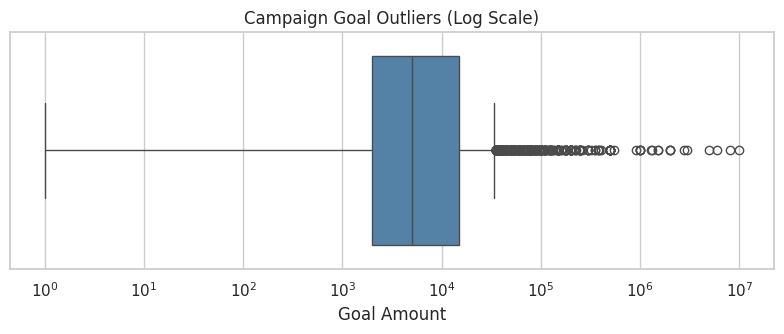

In [ ]:
# Goal box plot
plt.figure(figsize=(8, 3.5))
sns.boxplot(x=df["goal"], color="steelblue")
plt.xscale("log")
plt.title("Campaign Goal Outliers (Log Scale)")
plt.xlabel("Goal Amount")
plt.tight_layout()
plt.show()

Large goals can be real, so they were kept and later log-transformed.

## 7. Class Imbalance – If Applicable

In [ ]:
# Class percentages
class_pct = (df["success"].value_counts(normalize=True).sort_index() * 100).round(1)
print(f"Failed: {class_pct[0]}%")
print(f"Successful: {class_pct[1]}%")

Failed: 41.2%
Successful: 58.8%


The target is fairly balanced: 41% failed and 59% successful. Several metrics will still be used.

# Part 4 – Exploratory Data Analysis

## Numerical Analysis

In [ ]:
# Numerical summary
num_cols_eda = ["goal", "campaign_duration_days", "launch_year", "launch_month"]
numerical_summary = df[num_cols_eda].agg(["mean", "median", "std", "skew"]).T.round(2)
numerical_summary

,mean,median,std,skew
goal,30743.11,5000.0,270106.00,26.24
campaign_duration_days,33.21,30.0,12.24,1.05
launch_year,2014.39,2015.0,1.55,-0.93
launch_month,6.34,6.0,3.36,0.03


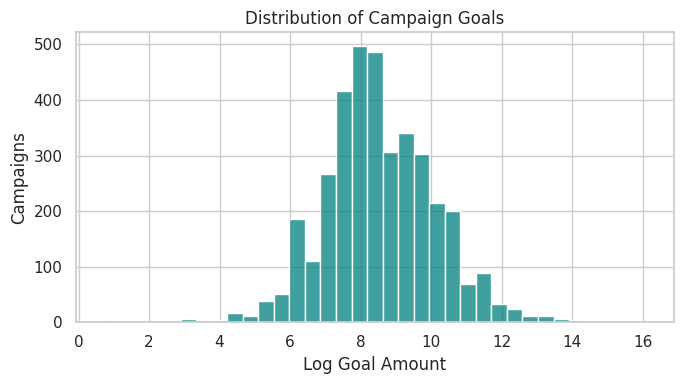

In [ ]:
# Distribution of campaign goals
plt.figure(figsize=(7, 4))
sns.histplot(np.log1p(df["goal"]), bins=35, color="teal")
plt.title("Distribution of Campaign Goals")
plt.xlabel("Log Goal Amount")
plt.ylabel("Campaigns")
plt.tight_layout()
plt.show()

Most goals are moderate, with a few very large values causing right skew.

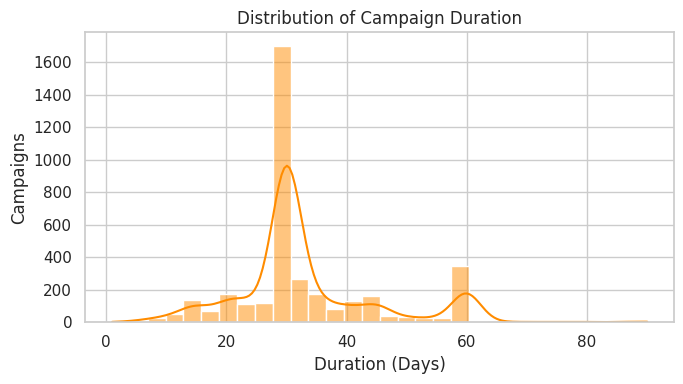

In [ ]:
# Distribution of campaign duration
plt.figure(figsize=(7, 4))
sns.histplot(df["campaign_duration_days"], bins=30, kde=True, color="darkorange")
plt.title("Distribution of Campaign Duration")
plt.xlabel("Duration (Days)")
plt.ylabel("Campaigns")
plt.tight_layout()
plt.show()

Most campaigns last around one month.

## Categorical Analysis

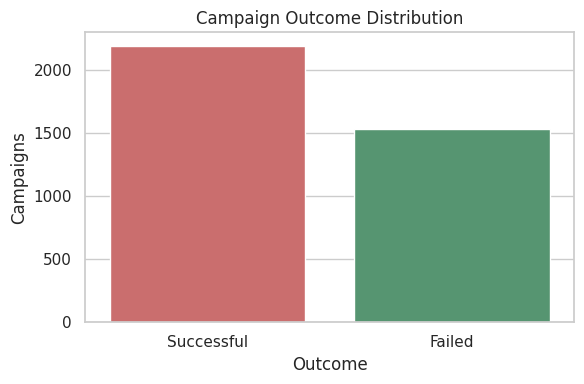

In [ ]:
# Target class chart
plot_target = df["success"].map({0: "Failed", 1: "Successful"})

plt.figure(figsize=(6, 4))
sns.countplot(x=plot_target, palette=["#d95f5f", "#4c9f70"])
plt.title("Campaign Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Campaigns")
plt.tight_layout()
plt.show()

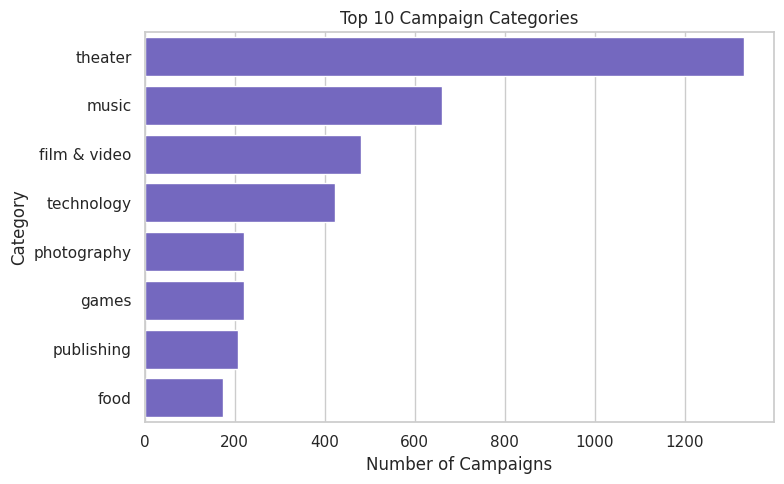

In [ ]:
# Top campaign categories
top_categories = df["category"].value_counts().head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_categories.values, y=top_categories.index, color="slateblue")
plt.title("Top 10 Campaign Categories")
plt.xlabel("Number of Campaigns")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

A few categories contain most campaigns, so category may help prediction.

## Relationship Analysis

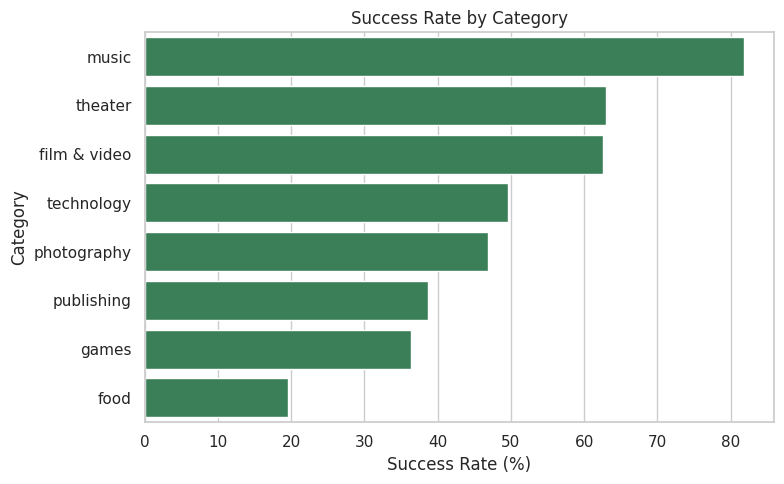

In [ ]:
# Success rate by category
category_success = (
    df.groupby("category")["success"]
      .agg(["mean", "count"])
      .query("count >= 50")
      .sort_values("mean", ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_success["mean"] * 100, y=category_success.index, color="seagreen")
plt.title("Success Rate by Category")
plt.xlabel("Success Rate (%)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

Success rates vary by category, making category useful for prediction.

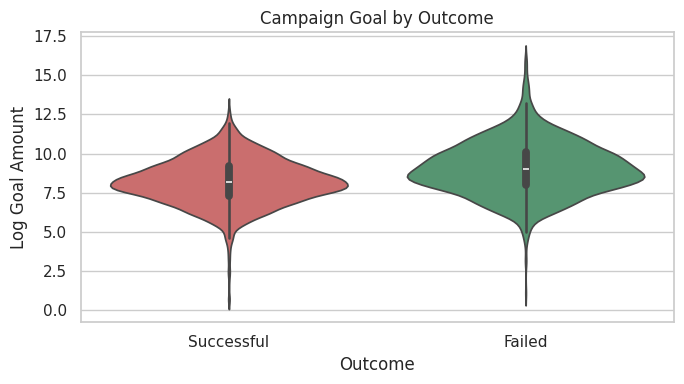

In [ ]:
# Goal amount by campaign outcome
eda_plot = df.assign(log_goal=np.log1p(df["goal"]), outcome=plot_target)

plt.figure(figsize=(7, 4))
sns.violinplot(data=eda_plot, x="outcome", y="log_goal", palette=["#d95f5f", "#4c9f70"])
plt.title("Campaign Goal by Outcome")
plt.xlabel("Outcome")
plt.ylabel("Log Goal Amount")
plt.tight_layout()
plt.show()

Failed campaigns usually have higher goals, but goal alone cannot separate the classes.

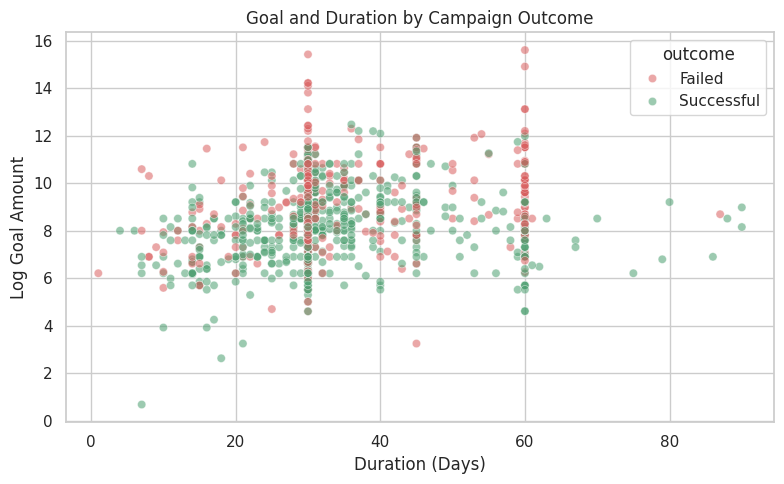

In [ ]:
# Campaign goal and duration relationship
plot_sample = eda_plot.sample(min(1200, len(eda_plot)), random_state=RANDOM_STATE)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_sample, x="campaign_duration_days", y="log_goal",
    hue="outcome", alpha=0.55, palette=["#d95f5f", "#4c9f70"]
)
plt.title("Goal and Duration by Campaign Outcome")
plt.xlabel("Duration (Days)")
plt.ylabel("Log Goal Amount")
plt.tight_layout()
plt.show()

Goal shows more separation than duration, but both classes still overlap.

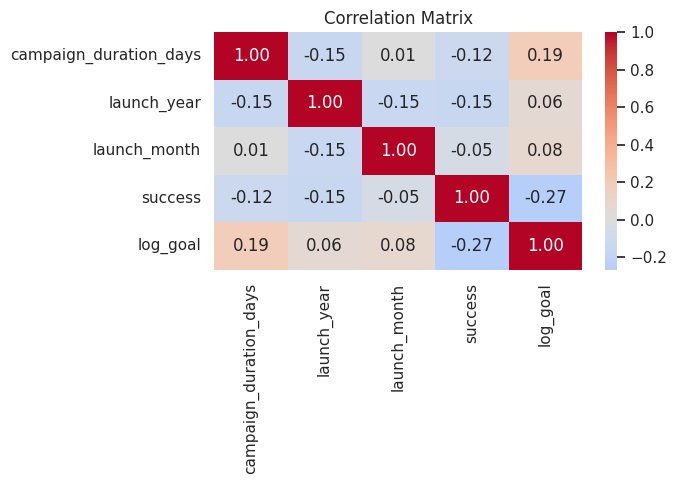

In [ ]:
# Correlation matrix
corr_data = df[["goal", "campaign_duration_days", "launch_year", "launch_month", "success"]].copy()
corr_data["log_goal"] = np.log1p(corr_data.pop("goal"))

plt.figure(figsize=(7, 5))
sns.heatmap(corr_data.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

No numerical feature predicts success alone; the model must combine features.

In [ ]:
# Grouped summary by outcome
grouped_summary = (
    df.groupby("success")[["goal", "campaign_duration_days"]]
      .median()
      .rename(index={0: "Failed", 1: "Successful"})
      .round(1)
)
grouped_summary

,goal,campaign_duration_days
success,,
Failed,8000.0,30.0
Successful,3500.0,30.0


## At least 5 meaningful insights from your EDA

1. Failed campaigns usually have higher goals.
2. Success rates differ across categories.
3. Most campaigns last around one month.
4. Goal values are highly right-skewed.
5. No single feature fully separates the outcomes.

# Part 5 – Feature Preparation

In [ ]:
# Create one simple engineered feature
df["log_goal"] = np.log1p(df["goal"])

# Remove identifier, raw dates, and the original skewed goal
drop_cols = ["campaign_id", "success", "launched_date", "deadline_date", "goal"]
X = df.drop(columns=drop_cols)
y = df["success"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Removed identifier: campaign_id")
print("Target: success")

X shape: (3715, 9)
y shape: (3715,)
Removed identifier: campaign_id
Target: success


In [ ]:
# Separate numerical and categorical features
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['campaign_duration_days', 'launch_year', 'launch_month', 'log_goal']
Categorical features: ['country', 'currency', 'category', 'subcategory', 'launch_weekday']


In [ ]:
# Preprocessing for all models
numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_preprocessor, numerical_features),
    ("cat", categorical_preprocessor, categorical_features)
])

print("Preprocessing ready: scaling for numbers and one-hot encoding for categories.")

Preprocessing ready: scaling for numbers and one-hot encoding for categories.


`campaign_id` and raw dates were removed. Numbers were scaled, categories encoded, and post-campaign variables excluded to prevent Data Leakage.

# Part 6 – Data Splitting

In [ ]:
# Create one shared 60/20/20 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print("Training set:", len(X_train), "rows (60%)")
print("Validation set:", len(X_val), "rows (20%)")
print("Test set:", len(X_test), "rows (20%)")

Training set: 2229 rows (60%)
Validation set: 743 rows (20%)
Test set: 743 rows (20%)


Training fits the models, validation selects them, and test evaluates the final model once. Stratification keeps the class ratio similar.

# Part 7 – Baseline Model

In [ ]:
# Logistic Regression baseline
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_val)

baseline_accuracy = accuracy_score(y_val, baseline_pred)
baseline_f1 = f1_score(y_val, baseline_pred)

print("Baseline: Logistic Regression")
print("Validation Accuracy:", round(baseline_accuracy, 3))
print("Validation F1:", round(baseline_f1, 3))
print("Underfitting:", "Possible" if baseline_f1 < 0.60 else "No clear evidence")

Baseline: Logistic Regression
Validation Accuracy: 0.869
Validation F1: 0.894
Underfitting: No clear evidence


Logistic Regression is a simple baseline. Other models should improve its validation F1 without overfitting.

# Part 8 – Machine Learning Model Development

Five suitable classification models were trained and compared.

In [ ]:
# Define the models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, min_samples_leaf=10, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=4,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=120, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE
    )
}

print("Models:", list(models.keys()))

Models: ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'Gradient Boosting']


## Model Justification (Part 8 Questions)

- **Logistic Regression:** Linear baseline that needs scaling. It learns feature weights and predicts probabilities. Main parameters: `C` and `penalty`. Fast and interpretable, but limited with nonlinear patterns.
- **KNN:** Nonlinear model that needs scaling. It stores training rows and predicts from nearby neighbors. Main parameters: `n_neighbors`, `weights`, and `metric`. Simple, but prediction can be slow.
- **Decision Tree:** Nonlinear model that does not need scaling. It learns if/else splits and predicts from leaf classes. Main parameters: `max_depth`, `min_samples_split`, and `min_samples_leaf`. Easy to explain, but can overfit.
- **Random Forest:** Nonlinear ensemble that does not need scaling. It trains many trees and combines their votes. Main parameters: `n_estimators`, `max_depth`, and `min_samples_leaf`. Stable, but less interpretable.
- **Gradient Boosting:** Nonlinear ensemble that does not need scaling. Each tree corrects earlier errors. Main parameters: `n_estimators`, `learning_rate`, and `max_depth`. Powerful, but sensitive to tuning.

# Part 9 – Model Evaluation

In [ ]:
# Train and evaluate every model on the same split
results = []
fitted_models = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe

    train_pred = pipe.predict(X_train)
    val_pred = pipe.predict(X_val)
    val_prob = pipe.predict_proba(X_val)[:, 1]

    results.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Val Accuracy": accuracy_score(y_val, val_pred),
        "Train F1": f1_score(y_train, train_pred),
        "Val F1": f1_score(y_val, val_pred),
        "Val Precision": precision_score(y_val, val_pred),
        "Val Recall": recall_score(y_val, val_pred),
        "Val ROC-AUC": roc_auc_score(y_val, val_prob)
    })

results_df = pd.DataFrame(results).sort_values("Val F1", ascending=False).reset_index(drop=True)
results_df.round(3)

,Model,Train Accuracy,Val Accuracy,Train F1,Val F1,Val Precision,Val Recall,Val ROC-AUC
0,Logistic Regression,0.855,0.869,0.884,0.894,0.853,0.941,0.939
1,Gradient Boosting,0.859,0.859,0.889,0.887,0.837,0.943,0.927
2,Random Forest,0.847,0.821,0.871,0.844,0.864,0.826,0.916
3,KNN,0.821,0.766,0.859,0.816,0.759,0.881,0.848
4,Decision Tree,0.749,0.720,0.809,0.787,0.712,0.881,0.771


F1 balances Precision and Recall. ROC-AUC measures how well the model separates the two classes.

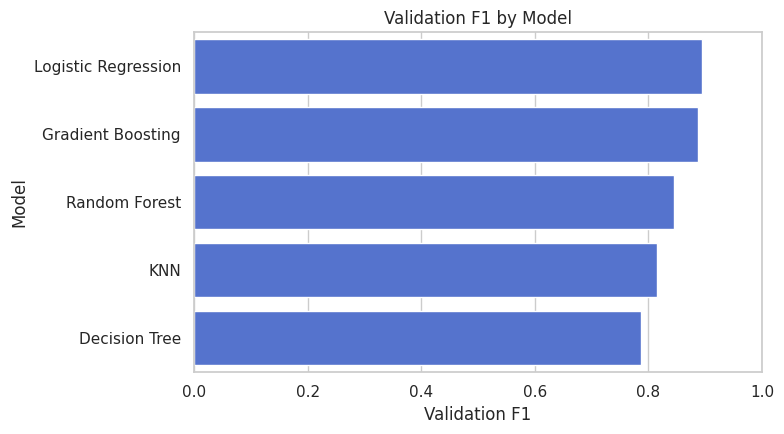

In [ ]:
# Validation F1 comparison
plt.figure(figsize=(8, 4.5))
sns.barplot(data=results_df, x="Val F1", y="Model", color="royalblue")
plt.xlim(0, 1)
plt.title("Validation F1 by Model")
plt.xlabel("Validation F1")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

In [ ]:
# Five-fold cross-validation on the training set
cv_rows = []
for name, pipe in fitted_models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="f1", n_jobs=-1)
    cv_rows.append({"Model": name, "CV F1 Mean": scores.mean(), "CV F1 Std": scores.std()})

cv_results = pd.DataFrame(cv_rows).sort_values("CV F1 Mean", ascending=False)
cv_results.round(3)

,Model,CV F1 Mean,CV F1 Std
0,Logistic Regression,0.882,0.004
4,Gradient Boosting,0.878,0.008
3,Random Forest,0.858,0.011
1,KNN,0.825,0.010
2,Decision Tree,0.794,0.006


Five-fold cross-validation checks whether model performance is stable.

# Part 10 – Overfitting and Underfitting Analysis

In [ ]:
# Compare training and validation F1
fit_analysis = results_df[["Model", "Train F1", "Val F1"]].copy()
fit_analysis["F1 Gap"] = fit_analysis["Train F1"] - fit_analysis["Val F1"]
fit_analysis["Behavior"] = np.select(
    [fit_analysis["F1 Gap"] > 0.10, fit_analysis["Val F1"] < 0.60],
    ["Possible overfitting", "Possible underfitting"],
    default="Generalizing reasonably"
)
fit_analysis.round(3)

,Model,Train F1,Val F1,F1 Gap,Behavior
0,Logistic Regression,0.884,0.894,-0.011,Generalizing reasonably
1,Gradient Boosting,0.889,0.887,0.002,Generalizing reasonably
2,Random Forest,0.871,0.844,0.027,Generalizing reasonably
3,KNN,0.859,0.816,0.043,Generalizing reasonably
4,Decision Tree,0.809,0.787,0.022,Generalizing reasonably


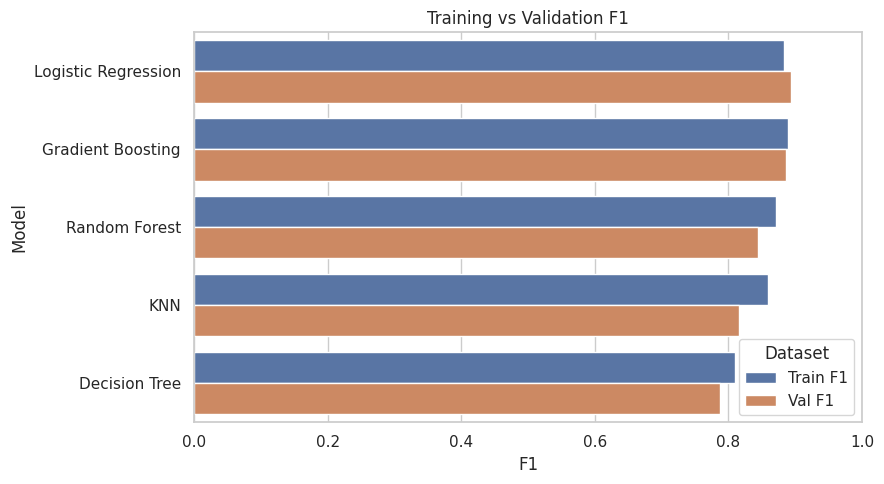

In [ ]:
# Training vs validation chart
fit_plot = fit_analysis.melt(
    id_vars="Model", value_vars=["Train F1", "Val F1"],
    var_name="Dataset", value_name="F1"
)

plt.figure(figsize=(9, 5))
sns.barplot(data=fit_plot, x="F1", y="Model", hue="Dataset")
plt.xlim(0, 1)
plt.title("Training vs Validation F1")
plt.tight_layout()
plt.show()

A large train-validation gap suggests overfitting; low scores on both suggest underfitting.

# Part 11 – Hyperparameter Experiments

## Random Forest: Effect of `max_depth`

In [ ]:
# Test several tree depths
depth_values = [3, 5, 8, 12, None]
rf_train_scores = []
rf_val_scores = []

for depth in depth_values:
    rf_pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=depth,
            min_samples_leaf=4,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
    rf_pipe.fit(X_train, y_train)
    rf_train_scores.append(f1_score(y_train, rf_pipe.predict(X_train)))
    rf_val_scores.append(f1_score(y_val, rf_pipe.predict(X_val)))

depth_labels = [str(x) for x in depth_values]
rf_tuning = pd.DataFrame({
    "max_depth": depth_labels,
    "Train F1": rf_train_scores,
    "Validation F1": rf_val_scores
})
rf_tuning.round(3)

,max_depth,Train F1,Validation F1
0,3,0.816,0.801
1,5,0.845,0.831
2,8,0.866,0.844
3,12,0.877,0.850
4,None,0.921,0.864


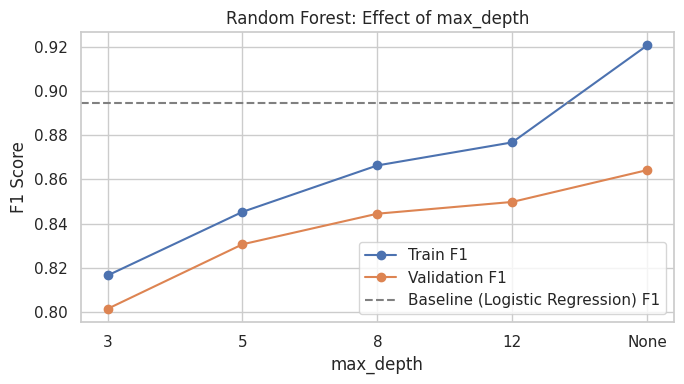

In [ ]:
# Plot the depth experiment
plt.figure(figsize=(7, 4))
plt.plot(depth_labels, rf_train_scores, marker="o", label="Train F1")
plt.plot(depth_labels, rf_val_scores, marker="o", label="Validation F1")
plt.xlabel("max_depth")
plt.ylabel("F1 Score")
plt.title("Random Forest: Effect of max_depth")
plt.axhline(baseline_f1, color="gray", linestyle="--", label="Baseline (Logistic Regression) F1")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Select depth using validation F1, then prefer the simpler depth in a near tie
best_val = max(rf_val_scores)
candidate_indexes = [i for i, score in enumerate(rf_val_scores) if score >= best_val - 0.01]
best_index = candidate_indexes[0]
best_depth = depth_values[best_index]

print("Selected max_depth:", best_depth)
print("Validation F1:", round(rf_val_scores[best_index], 3))
print("Train-validation gap:", round(rf_train_scores[best_index] - rf_val_scores[best_index], 3))

Selected max_depth: None
Validation F1: 0.864
Train-validation gap: 0.056


Greater depth increases complexity and overfitting risk. The selected depth gave strong validation F1 with a reasonable gap.

## KNN: Effect of `n_neighbors`


In [ ]:
# Test several values of n_neighbors
k_values = [1, 3, 5, 15, 25, 50]
knn_train_scores = []
knn_val_scores = []

for k in k_values:
    knn_pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=k))
    ])
    knn_pipe.fit(X_train, y_train)
    knn_train_scores.append(f1_score(y_train, knn_pipe.predict(X_train)))
    knn_val_scores.append(f1_score(y_val, knn_pipe.predict(X_val)))

knn_tuning = pd.DataFrame({
    "n_neighbors": k_values,
    "Train F1": knn_train_scores,
    "Validation F1": knn_val_scores
})
knn_tuning.round(3)


,n_neighbors,Train F1,Validation F1
0,1,0.998,0.794
1,3,0.905,0.804
2,5,0.887,0.819
3,15,0.859,0.816
4,25,0.845,0.826
5,50,0.817,0.804


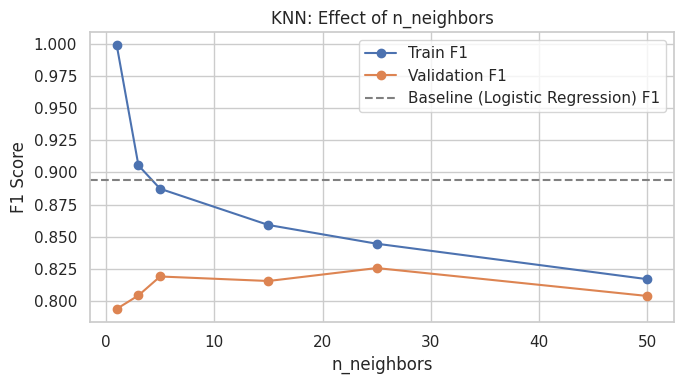

In [ ]:
# Plot the n_neighbors experiment
plt.figure(figsize=(7, 4))
plt.plot(k_values, knn_train_scores, marker="o", label="Train F1")
plt.plot(k_values, knn_val_scores, marker="o", label="Validation F1")
plt.xlabel("n_neighbors")
plt.ylabel("F1 Score")
plt.title("KNN: Effect of n_neighbors")
plt.axhline(baseline_f1, color="gray", linestyle="--", label="Baseline (Logistic Regression) F1")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Select n_neighbors using validation F1, then prefer the simpler (larger k) model in a near tie
best_val_knn = max(knn_val_scores)
knn_candidates = [i for i, score in enumerate(knn_val_scores) if score >= best_val_knn - 0.01]
best_knn_index = knn_candidates[-1]
best_k = k_values[best_knn_index]

print("Selected n_neighbors:", best_k)
print("Validation F1:", round(knn_val_scores[best_knn_index], 3))
print("Train-validation gap:", round(knn_train_scores[best_knn_index] - knn_val_scores[best_knn_index], 3))


Selected n_neighbors: 25
Validation F1: 0.826
Train-validation gap: 0.019


Small `n_neighbors` may overfit; very large values may underfit. The selected value balanced validation F1 and generalization.

## Gradient Boosting: Effect of `learning_rate`


In [ ]:
# Test several values of learning_rate
lr_values = [0.01, 0.05, 0.1, 0.2, 0.4]
gb_train_scores = []
gb_val_scores = []

for lr in lr_values:
    gb_pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(
            n_estimators=120, learning_rate=lr, max_depth=3, random_state=RANDOM_STATE
        ))
    ])
    gb_pipe.fit(X_train, y_train)
    gb_train_scores.append(f1_score(y_train, gb_pipe.predict(X_train)))
    gb_val_scores.append(f1_score(y_val, gb_pipe.predict(X_val)))

gb_tuning = pd.DataFrame({
    "learning_rate": lr_values,
    "Train F1": gb_train_scores,
    "Validation F1": gb_val_scores
})
gb_tuning.round(3)


,learning_rate,Train F1,Validation F1
0,0.01,0.818,0.803
1,0.05,0.889,0.887
2,0.10,0.897,0.899
3,0.20,0.913,0.890
4,0.40,0.934,0.878


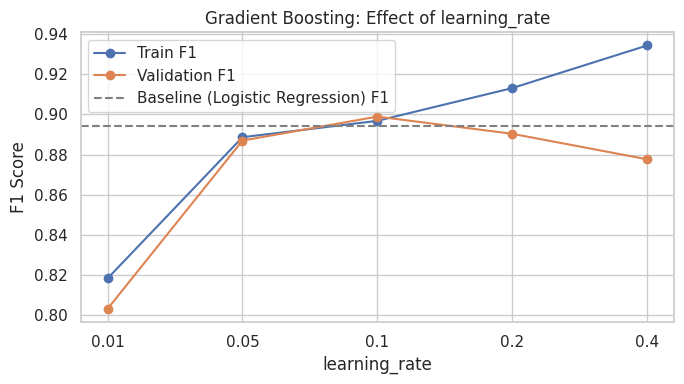

In [ ]:
# Plot the learning_rate experiment
plt.figure(figsize=(7, 4))
plt.plot([str(x) for x in lr_values], gb_train_scores, marker="o", label="Train F1")
plt.plot([str(x) for x in lr_values], gb_val_scores, marker="o", label="Validation F1")
plt.xlabel("learning_rate")
plt.ylabel("F1 Score")
plt.title("Gradient Boosting: Effect of learning_rate")
plt.axhline(baseline_f1, color="gray", linestyle="--", label="Baseline (Logistic Regression) F1")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Select learning_rate using validation F1, then prefer the smaller (more conservative) rate in a near tie
best_val_gb = max(gb_val_scores)
gb_candidates = [i for i, score in enumerate(gb_val_scores) if score >= best_val_gb - 0.01]
best_gb_index = gb_candidates[0]
best_lr = lr_values[best_gb_index]

print("Selected learning_rate:", best_lr)
print("Validation F1:", round(gb_val_scores[best_gb_index], 3))
print("Train-validation gap:", round(gb_train_scores[best_gb_index] - gb_val_scores[best_gb_index], 3))


Selected learning_rate: 0.1
Validation F1: 0.899
Train-validation gap: -0.002


A low `learning_rate` may underfit, while a high value may overfit. The selected value balanced performance and complexity.

## Logistic Regression: Effect of `C`


In [ ]:
# Test several values of C (inverse regularization strength)
c_values = [0.001, 0.01, 0.1, 1, 10, 100]
logreg_train_scores = []
logreg_val_scores = []

for c in c_values:
    logreg_pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(C=c, max_iter=1000, random_state=RANDOM_STATE))
    ])
    logreg_pipe.fit(X_train, y_train)
    logreg_train_scores.append(f1_score(y_train, logreg_pipe.predict(X_train)))
    logreg_val_scores.append(f1_score(y_val, logreg_pipe.predict(X_val)))

logreg_tuning = pd.DataFrame({
    "C": c_values,
    "Train F1": logreg_train_scores,
    "Validation F1": logreg_val_scores
})
logreg_tuning.round(3)


,C,Train F1,Validation F1
0,0.001,0.765,0.763
1,0.010,0.789,0.787
2,0.100,0.876,0.870
3,1.000,0.884,0.894
4,10.000,0.888,0.892
5,100.000,0.888,0.891


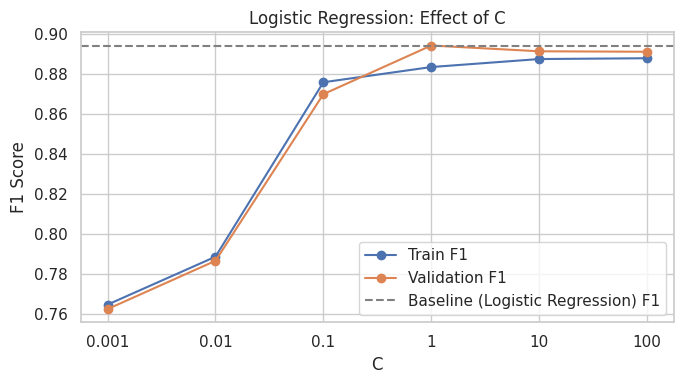

In [ ]:
# Plot the C experiment
plt.figure(figsize=(7, 4))
plt.plot([str(x) for x in c_values], logreg_train_scores, marker="o", label="Train F1")
plt.plot([str(x) for x in c_values], logreg_val_scores, marker="o", label="Validation F1")
plt.xlabel("C")
plt.ylabel("F1 Score")
plt.title("Logistic Regression: Effect of C")
plt.axhline(baseline_f1, color="gray", linestyle="--", label="Baseline (Logistic Regression) F1")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Select C using validation F1, then prefer the smaller (more regularized) value in a near tie
best_val_logreg = max(logreg_val_scores)
logreg_candidates = [i for i, score in enumerate(logreg_val_scores) if score >= best_val_logreg - 0.01]
best_logreg_index = logreg_candidates[0]
best_c = c_values[best_logreg_index]

print("Selected C:", best_c)
print("Validation F1:", round(logreg_val_scores[best_logreg_index], 3))
print("Train-validation gap:", round(logreg_train_scores[best_logreg_index] - logreg_val_scores[best_logreg_index], 3))


Selected C: 1
Validation F1: 0.894
Train-validation gap: -0.011


Small `C` uses stronger regularization and may underfit; large `C` may overfit. The selected value kept strong validation F1.

## Decision Tree: Effect of `min_samples_leaf`


In [ ]:
# Test several values of min_samples_leaf
leaf_values = [1, 2, 5, 10, 20, 50]
dt_train_scores = []
dt_val_scores = []

for leaf in leaf_values:
    dt_pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            min_samples_leaf=leaf, random_state=RANDOM_STATE
        ))
    ])
    dt_pipe.fit(X_train, y_train)
    dt_train_scores.append(f1_score(y_train, dt_pipe.predict(X_train)))
    dt_val_scores.append(f1_score(y_val, dt_pipe.predict(X_val)))

dt_tuning = pd.DataFrame({
    "min_samples_leaf": leaf_values,
    "Train F1": dt_train_scores,
    "Validation F1": dt_val_scores
})
dt_tuning.round(3)


,min_samples_leaf,Train F1,Validation F1
0,1,0.999,0.828
1,2,0.955,0.835
2,5,0.917,0.837
3,10,0.889,0.841
4,20,0.848,0.809
5,50,0.750,0.705


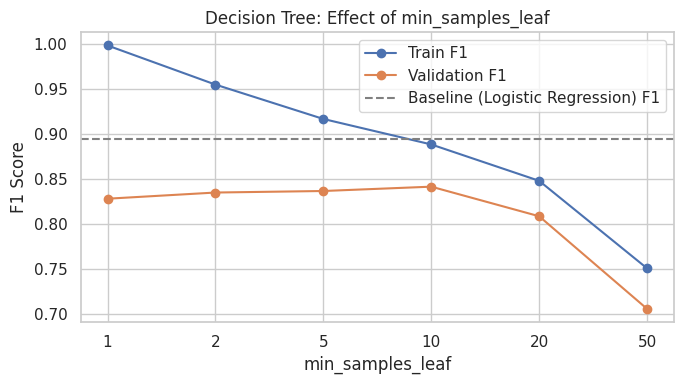

In [ ]:
# Plot the min_samples_leaf experiment
plt.figure(figsize=(7, 4))
plt.plot([str(x) for x in leaf_values], dt_train_scores, marker="o", label="Train F1")
plt.plot([str(x) for x in leaf_values], dt_val_scores, marker="o", label="Validation F1")
plt.xlabel("min_samples_leaf")
plt.ylabel("F1 Score")
plt.title("Decision Tree: Effect of min_samples_leaf")
plt.axhline(baseline_f1, color="gray", linestyle="--", label="Baseline (Logistic Regression) F1")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Select min_samples_leaf using validation F1, then prefer the larger (simpler) value in a near tie
best_val_dt = max(dt_val_scores)
dt_candidates = [i for i, score in enumerate(dt_val_scores) if score >= best_val_dt - 0.01]
best_dt_index = dt_candidates[-1]
best_leaf = leaf_values[best_dt_index]

print("Selected min_samples_leaf:", best_leaf)
print("Validation F1:", round(dt_val_scores[best_dt_index], 3))
print("Train-validation gap:", round(dt_train_scores[best_dt_index] - dt_val_scores[best_dt_index], 3))


Selected min_samples_leaf: 10
Validation F1: 0.841
Train-validation gap: 0.047


Small leaves may overfit; larger leaves simplify the tree and may eventually underfit. The selected value gave the best balance.

## Hyperparameter Tuning vs Baseline


In [ ]:
# Compare the best validation F1 from each tuning experiment against the baseline
tuning_summary = pd.DataFrame({
    "Model": ["Baseline (Logistic Regression, default)", "Logistic Regression (tuned C)",
              "KNN (tuned n_neighbors)", "Decision Tree (tuned min_samples_leaf)",
              "Random Forest (tuned max_depth)", "Gradient Boosting (tuned learning_rate)"],
    "Best Validation F1": [
        baseline_f1,
        logreg_val_scores[best_logreg_index],
        knn_val_scores[best_knn_index],
        dt_val_scores[best_dt_index],
        rf_val_scores[best_index],
        gb_val_scores[best_gb_index],
    ]
})
tuning_summary["Improvement over Baseline"] = tuning_summary["Best Validation F1"] - baseline_f1
tuning_summary.round(3)


,Model,Best Validation F1,Improvement over Baseline
0,"Baseline (Logistic Regression, default)",0.894,0.000
1,Logistic Regression (tuned C),0.894,0.000
2,KNN (tuned n_neighbors),0.826,-0.069
3,Decision Tree (tuned min_samples_leaf),0.841,-0.053
4,Random Forest (tuned max_depth),0.864,-0.030
5,Gradient Boosting (tuned learning_rate),0.899,0.004


Gradient Boosting slightly beat the baseline (`0.899` vs `0.894`). The other tuned models scored lower, so tuning did not guarantee improvement.

# Part 12 – Model Comparison and Selection

In [ ]:
# Add model characteristics to the comparison
model_notes = pd.DataFrame({
    "Model": list(models.keys()),
    "Scaling": ["Yes", "Yes", "No", "No", "No"],
    "Main Strength": [
        "Simple baseline", "Local patterns", "Readable rules",
        "Stable nonlinear model", "Strong pattern learning"
    ],
    "Main Limitation": [
        "Mostly linear", "Slow prediction", "Can overfit",
        "Less interpretable", "Needs careful tuning"
    ]
})

comparison = (
    results_df.merge(cv_results, on="Model")
              .merge(model_notes, on="Model")
)
comparison.round(3)

,Model,Train Accuracy,Val Accuracy,Train F1,Val F1,Val Precision,Val Recall,Val ROC-AUC,CV F1 Mean,CV F1 Std,Scaling,Main Strength,Main Limitation
0,Logistic Regression,0.855,0.869,0.884,0.894,0.853,0.941,0.939,0.882,0.004,Yes,Simple baseline,Mostly linear
1,Gradient Boosting,0.859,0.859,0.889,0.887,0.837,0.943,0.927,0.878,0.008,No,Strong pattern learning,Needs careful tuning
2,Random Forest,0.847,0.821,0.871,0.844,0.864,0.826,0.916,0.858,0.011,No,Stable nonlinear model,Less interpretable
3,KNN,0.821,0.766,0.859,0.816,0.759,0.881,0.848,0.825,0.010,Yes,Local patterns,Slow prediction
4,Decision Tree,0.749,0.720,0.809,0.787,0.712,0.881,0.771,0.794,0.006,No,Readable rules,Can overfit


In [ ]:
# Choose the final model using performance and generalization
selection_table = comparison.copy()
selection_table["Gap"] = selection_table["Train F1"] - selection_table["Val F1"]
selection_table["Selection Score"] = (
    selection_table["Val F1"]
    + 0.20 * selection_table["Val ROC-AUC"]
    - 0.30 * selection_table["Gap"].clip(lower=0)
)

final_model_name = selection_table.sort_values("Selection Score", ascending=False).iloc[0]["Model"]

if final_model_name == "Random Forest":
    final_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200, max_depth=best_depth, min_samples_leaf=4,
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
        ))
    ])
else:
    final_model = fitted_models[final_model_name]

print("Final selected model:", final_model_name)
print("Reason: strong validation results with a controlled generalization gap.")

selected_row = selection_table[selection_table["Model"] == final_model_name].iloc[0]
print("Validation F1:", round(selected_row["Val F1"], 3))
print("Generalization gap:", round(selected_row["Gap"], 3))
print("Clearly outperformed baseline:", "Yes" if selected_row["Val F1"] > baseline_f1 + 0.02 else "No")
print("Interpretability:", "High" if final_model_name in ["Logistic Regression", "Decision Tree"] else "Moderate")
print("Computational cost:", "Low" if final_model_name == "Logistic Regression" else "Moderate")
print("Real-world fit: Appropriate as an early screening tool.")

Final selected model: Logistic Regression
Reason: strong validation results with a controlled generalization gap.
Validation F1: 0.894
Generalization gap: -0.011
Clearly outperformed baseline: No
Interpretability: High
Computational cost: Low
Real-world fit: Appropriate as an early screening tool.


In [ ]:
# Refit the selected model on training + validation data
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])

final_model.fit(X_train_final, y_train_final)
test_pred = final_model.predict(X_test)
test_prob = final_model.predict_proba(X_test)[:, 1]

test_scores = {
    "Accuracy": accuracy_score(y_test, test_pred),
    "Precision": precision_score(y_test, test_pred),
    "Recall": recall_score(y_test, test_pred),
    "F1": f1_score(y_test, test_pred),
    "ROC-AUC": roc_auc_score(y_test, test_prob)
}

print("Final Test Results")
for metric, value in test_scores.items():
    print(f"{metric}: {value:.3f}")

Final Test Results
Accuracy: 0.856
Precision: 0.837
Recall: 0.938
F1: 0.885
ROC-AUC: 0.930


The test set was used once. The final model is useful for early screening, not as a guarantee.

# Part 13 – Error Analysis

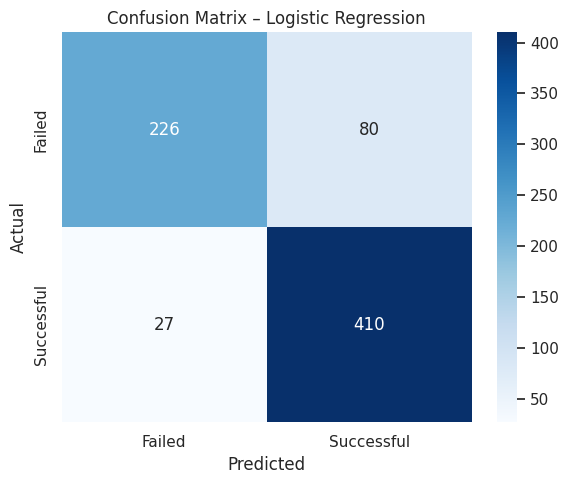

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Failed", "Successful"],
    yticklabels=["Failed", "Successful"]
)
plt.title(f"Confusion Matrix – {final_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:
# Count false positives and false negatives
false_positives = ((y_test == 0) & (test_pred == 1)).sum()
false_negatives = ((y_test == 1) & (test_pred == 0)).sum()

print("False Positives (predicted success but failed):", false_positives)
print("False Negatives (predicted failure but succeeded):", false_negatives)
print("Most common error:", "False Positives" if false_positives > false_negatives else "False Negatives")

False Positives (predicted success but failed): 80
False Negatives (predicted failure but succeeded): 27
Most common error: False Positives


In [ ]:
# Compare misclassified and correct campaigns
error_data = X_test[["log_goal", "campaign_duration_days"]].copy()
error_data["actual"] = y_test.values
error_data["predicted"] = test_pred
error_data["result"] = np.where(error_data["actual"] == error_data["predicted"], "Correct", "Misclassified")

error_data.groupby("result")[["log_goal", "campaign_duration_days"]].median().round(2)

,log_goal,campaign_duration_days
result,,
Correct,8.52,30.0
Misclassified,8.41,30.0


## At least 3 meaningful findings from your Error Analysis

1. False positives are more costly because they predict success for failed campaigns.
2. Misclassified campaigns look similar to the opposite class.
3. Missing factors such as marketing and audience size may explain some errors.

# Part 14 – Unsupervised Learning: Clustering

## Feature Selection

Clustering uses goal, duration, launch year, and launch month without the target.

In [ ]:
# Prepare numerical clustering features without the target
cluster_features = ["log_goal", "campaign_duration_days", "launch_year", "launch_month"]
cluster_data = df[cluster_features].copy()

cluster_scaler = StandardScaler()
cluster_scaled = cluster_scaler.fit_transform(cluster_data)

print("Clustering features:", cluster_features)
print("Target used in clustering: No")

Clustering features: ['log_goal', 'campaign_duration_days', 'launch_year', 'launch_month']
Target used in clustering: No


Scaling is needed because clustering compares distances between features.

In [ ]:
# Choose K using silhouette scores
k_values = [2, 3, 4, 5, 6]
k_scores = []

for k in k_values:
    labels = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(cluster_scaled)
    k_scores.append(silhouette_score(cluster_scaled, labels))

best_k = k_values[int(np.argmax(k_scores))]

for k, score in zip(k_values, k_scores):
    print(f"K={k}: Silhouette={score:.3f}")
print("Selected K:", best_k)

K=2: Silhouette=0.204
K=3: Silhouette=0.228
K=4: Silhouette=0.243
K=5: Silhouette=0.231
K=6: Silhouette=0.208
Selected K: 4


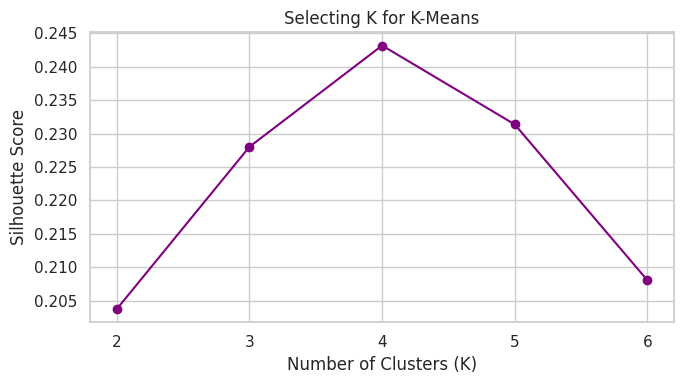

In [ ]:
# Silhouette score chart
plt.figure(figsize=(7, 4))
plt.plot(k_values, k_scores, marker="o", color="purple")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Selecting K for K-Means")
plt.xticks(k_values)
plt.tight_layout()
plt.show()

In [ ]:
# Fit K-Means and GMM
kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE)
gmm = GaussianMixture(n_components=best_k, random_state=RANDOM_STATE)

df["kmeans_cluster"] = kmeans.fit_predict(cluster_scaled)
df["gmm_cluster"] = gmm.fit_predict(cluster_scaled)

kmeans_silhouette = silhouette_score(cluster_scaled, df["kmeans_cluster"])
gmm_silhouette = silhouette_score(cluster_scaled, df["gmm_cluster"])

print("K-Means silhouette:", round(kmeans_silhouette, 3))
print("GMM silhouette:", round(gmm_silhouette, 3))

K-Means silhouette: 0.243
GMM silhouette: 0.207


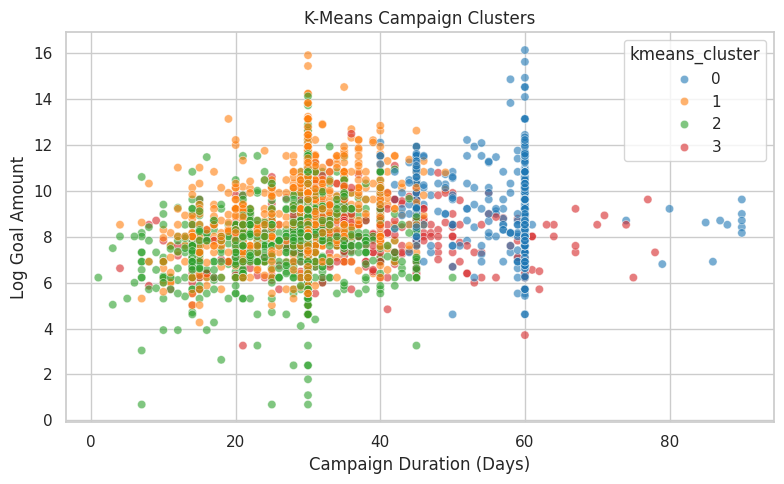

In [ ]:
# Visualize K-Means clusters using two original features
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df, x="campaign_duration_days", y="log_goal",
    hue="kmeans_cluster", palette="tab10", alpha=0.6
)
plt.title("K-Means Campaign Clusters")
plt.xlabel("Campaign Duration (Days)")
plt.ylabel("Log Goal Amount")
plt.tight_layout()
plt.show()

In [ ]:
# Cluster sizes and profiles
cluster_sizes = df["kmeans_cluster"].value_counts().sort_index().rename("Size")
cluster_profiles = df.groupby("kmeans_cluster")[cluster_features].mean().round(2)
cluster_profiles.insert(0, "Size", cluster_sizes)
cluster_profiles

,Size,log_goal,campaign_duration_days,launch_year,launch_month
kmeans_cluster,,,,,
0,473,9.17,56.79,2014.71,5.99
1,1320,9.01,29.26,2014.67,9.25
2,1333,8.06,27.95,2015.19,3.60
3,589,8.12,34.99,2011.67,6.30


In [ ]:
# Simple automatic cluster interpretation
overall_goal = df["log_goal"].mean()
overall_duration = df["campaign_duration_days"].mean()

for cluster_id, row in cluster_profiles.iterrows():
    goal_level = "higher" if row["log_goal"] > overall_goal else "lower"
    duration_level = "longer" if row["campaign_duration_days"] > overall_duration else "shorter"
    print(f"Cluster {cluster_id}: {goal_level} goals and {duration_level} campaigns ({int(row['Size'])} rows).")

Cluster 0: higher goals and longer campaigns (473 rows).
Cluster 1: higher goals and shorter campaigns (1320 rows).
Cluster 2: lower goals and shorter campaigns (1333 rows).
Cluster 3: lower goals and longer campaigns (589 rows).


The clusters represent campaign profiles based mainly on goal and duration, not success classes.

# Part 15 – Dimensionality Reduction Using PCA

PCA reduces the number of features while keeping most of the information.

In [ ]:
# Prepare and scale features for PCA
X_train_ready = preprocessor.fit_transform(X_train)
X_val_ready = preprocessor.transform(X_val)

print("Original input features:", X.shape[1])
print("Features after encoding:", X_train_ready.shape[1])

Original input features: 9
Features after encoding: 90


In [ ]:
# Find components needed to preserve 95% of the variance
pca_full = PCA()
pca_full.fit(X_train_ready)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.argmax(cumulative_variance >= 0.95) + 1

print("Components for 95% variance:", n_components)
print("Variance preserved:", f"{cumulative_variance[n_components - 1] * 100:.1f}%")

Components for 95% variance: 27
Variance preserved: 95.3%


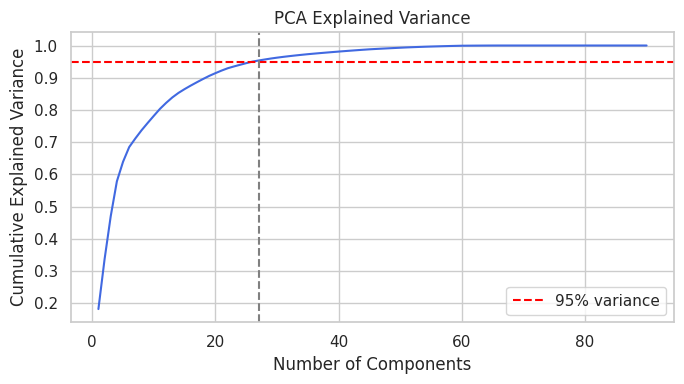

In [ ]:
# Plot cumulative explained variance
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, color="royalblue")
plt.axhline(0.95, color="red", linestyle="--", label="95% variance")
plt.axvline(n_components, color="gray", linestyle="--")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Apply PCA to training and validation data
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_ready)
X_val_pca = pca.transform(X_val_ready)

print("Before PCA:", X_train_ready.shape[1], "features")
print("After PCA:", X_train_pca.shape[1], "components")

Before PCA: 90 features
After PCA: 27 components


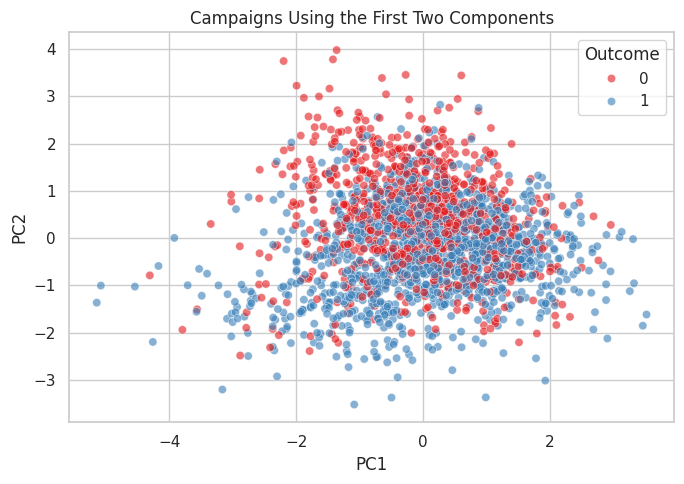

In [ ]:
# Visualize the first two principal components
pca_plot = pd.DataFrame({"PC1": X_train_pca[:, 0], "PC2": X_train_pca[:, 1], "Outcome": y_train.values})

plt.figure(figsize=(7, 5))
sns.scatterplot(data=pca_plot, x="PC1", y="PC2", hue="Outcome", alpha=0.6, palette="Set1")
plt.title("Campaigns Using the First Two Components")
plt.tight_layout()
plt.show()

In [ ]:
# Compare Logistic Regression before and after PCA
model_before_pca = LogisticRegression(max_iter=1000, random_state=42)
model_before_pca.fit(X_train_ready, y_train)
pred_before_pca = model_before_pca.predict(X_val_ready)

model_after_pca = LogisticRegression(max_iter=1000, random_state=42)
model_after_pca.fit(X_train_pca, y_train)
pred_after_pca = model_after_pca.predict(X_val_pca)

pca_comparison = pd.DataFrame({
    "Model": ["Without PCA", "With PCA"],
    "Features": [X_train_ready.shape[1], X_train_pca.shape[1]],
    "Accuracy": [accuracy_score(y_val, pred_before_pca), accuracy_score(y_val, pred_after_pca)],
    "F1": [f1_score(y_val, pred_before_pca), f1_score(y_val, pred_after_pca)]
})
pca_comparison.round(3)

,Model,Features,Accuracy,F1
0,Without PCA,90,0.869,0.894
1,With PCA,27,0.756,0.804


In [ ]:
# PCA conclusion
f1_before_pca = pca_comparison.loc[0, "F1"]
f1_after_pca = pca_comparison.loc[1, "F1"]

print("Original dimensions:", X_train_ready.shape[1])
print("Retained components:", n_components)
print("Variance preserved:", f"{pca.explained_variance_ratio_.sum() * 100:.1f}%")
print("F1 before PCA:", round(f1_before_pca, 3))
print("F1 after PCA:", round(f1_after_pca, 3))
print("Performance:", "Improved" if f1_after_pca > f1_before_pca else "Decreased or stayed similar")
print("PCA simplified the data:", "Yes" if n_components < X_train_ready.shape[1] else "No")

Original dimensions: 90
Retained components: 27
Variance preserved: 95.3%
F1 before PCA: 0.894
F1 after PCA: 0.804
Performance: Decreased or stayed similar
PCA simplified the data: Yes


PCA reduced 90 encoded features to 27 components and preserved 95.3% of the variance. However, F1 dropped from 0.894 to 0.804, so PCA simplified the data but did not improve prediction.

# Part 16 – Final Insights and Recommendations

- **EDA:** Goal and category were the clearest signals.
- **Preprocessing:** Log transformation, encoding, scaling, and leakage prevention were important.
- **Best result:** Gradient Boosting had the highest tuned Validation F1, but only slightly beat the baseline.
- **Generalization:** Training and validation scores were compared before selection.
- **Errors:** Overlapping campaign profiles were harder to classify.
- **Clustering:** Groups mainly differed by goal and duration.
- **PCA:** Reduced 90 features to 27, but F1 decreased to 0.804.
- **Limitation:** Marketing, audience size, and creator history were unavailable.
- **Recommendation:** Use the model as support, not as a final decision.

# Part 17 – Reflection

- **Main challenge:** Preventing Data Leakage.
- **Critical decision:** Using only information available at launch.
- **Tuning lesson:** More complex models were not always better.
- **Selection lesson:** Compare performance, generalization, simplicity, and cost.
- **Next step:** Add marketing and creator-history features.
- **Main learning:** Good ML needs clean data, fair evaluation, and clear interpretation.

## Dataset Source

Kickstarter Crowdfunding Success Analysis:  
https://github.com/kiranrangaraj/Kickerstarter-Crowdfunding-Success-Analysis